# Conspiracy Epistemic subDoc

## couple of new pieces of analysis separate from the master doc

Duplicated most of the stuff at the beginning of the master nb so that i can use all the imports etc

## 0. Imports and File Paths

This section establishes the technical environment for the analysis, configuring project library imports, setting project-relative file paths, and opening a shared connection to the DuckDB database to support fast querying of the large-scale parquet datasets.

In [1]:
import time

In [2]:
import re
import os
import duckdb
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
from IPython.display import HTML, display
from utils.duckdb_helpers import cached_query_csv
import time
from src.translation import (
    fetch_pubmed_metadata, translate_wikipedia_url,
    fetch_youtube_metadata, fetch_article_title,
    fetch_article_titles_batch, resolve_titles_with_reddit_first,
)

# --- File paths (all outputs live under BASE) ---
# Repo root is resolved by walking up from the notebook's working directory
# looking for CLAUDE.md, so this works regardless of where Jupyter was
# launched from or where the repo is cloned to (no hardcoded /Users/... path).
from pathlib import Path

def _find_repo_root(marker='CLAUDE.md'):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    return p  # fallback: assume launched from repo root

REPO_ROOT = _find_repo_root()
BASE = str(REPO_ROOT / 'data' / 'processed') + '/'
RAW_COMMENTS = str(REPO_ROOT / 'data' / 'raw' / 'r_conspiracy_comments*.jsonl*')
RAW_POSTS = str(REPO_ROOT / 'data' / 'raw' / 'r_conspiracy_posts*.jsonl*')
COMMENTS_GLOB = RAW_COMMENTS  # alias kept for the Section 9.7-9.8 queries
LEXICAL = BASE + 'lexical_scores_full.parquet'
EMPATH = BASE + 'empath_scores_full.parquet'
SPACY = BASE + 'spacy_attributed_comments.parquet'
SYNTHESIS = BASE + 'master_thread_synthesis.parquet'
LABELS = BASE + 'human_labels_active_learning.csv'

pd.set_option('display.max_colwidth', None)

# Single DuckDB connection reused across the notebook
con = duckdb.connect()

display(HTML("""
<style>
    .dataframe td {
        white-space: normal !important;
        word-wrap: break-word;
        max-width: 300px;
    }
    .dataframe th { max-width: 300px; }
</style>
"""))
print("Ready.")


Ready.


In [6]:
os.getcwd()

'/Users/nash/Projects/ConspiracyComments'

In [9]:
recdat = {}

# Get list of files, sort by modification time descending, and slice first x
files = ['link_source_tier_regression_results.csv',
         'trump_vs_classical_regression_results.csv',
         'politics_overlap_excluded_comparison.csv',
         'subreddit_interaction_results.csv',
         'refined_semantic_keyness_results_v2.csv',
         'refined_regression_results_v2.csv',
         'topic_time_regression_results_pure_50k.csv',
         'synthesis_interaction_results.csv',
         'synthesis_regression_results_filtered.csv']

for x in range(len(files)):
    recdat[x] = pd.read_csv(BASE + files[x])
         


    

In [11]:
dfdict = dict(zip(files,recdat.values()))

In [27]:
_poe = dfdict.get("politics_overlap_excluded_comparison.csv")
if _poe is not None and _poe["coef_full"].nunique() <= 1:
    print("⚠️ politics_overlap_excluded_comparison.csv is BROKEN (broadcast bug) — do not cite until Antigravity reruns run_subtask_b")

⚠️ politics_overlap_excluded_comparison.csv is BROKEN (broadcast bug) — do not cite until Antigravity reruns run_subtask_b


In [28]:
PROVISIONAL_COHORTS = {"r/politics"}  # update this once the ~140k expansion lands

def flag_provisional(df, cohort_col):
    df = df.copy()
    df["provisional_n"] = df[cohort_col].isin(PROVISIONAL_COHORTS)
    return df

dfdict["link_source_tier_regression_results.csv"] = flag_provisional(
    dfdict["link_source_tier_regression_results.csv"], "subreddit")
dfdict["refined_regression_results_v2.csv"] = flag_provisional(
    dfdict["refined_regression_results_v2.csv"], "subreddit")

In [37]:
def forest(df, variable, cohort_col="subreddit", title=None):
    d = df[df["variable"] == variable].dropna(subset=["coef", "se"]).sort_values("coef")
    fig, ax = plt.subplots(figsize=(6, 0.5*len(d)+1))
    is_prov = d["provisional_n"] if "provisional_n" in d.columns else pd.Series(False, index=d.index)
    colors = ["tab:orange" if p else "tab:blue" for p in is_prov]
    for i, (_, row) in enumerate(d.iterrows()):
        ax.errorbar(row["coef"], i, xerr=1.96*row["se"], fmt="o", capsize=3,
                    color=colors[i], ecolor=colors[i])
    ax.axvline(0, color="gray", ls="--")
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d[cohort_col], fontsize=9)
    ax.set_title((title or variable) + ("  (orange = provisional N)" if is_prov.any() else ""))
    return fig

In [30]:
long_bits = []
for fname, cohort_col in [("refined_regression_results_v2.csv", "subreddit"),
                           ("link_source_tier_regression_results.csv", "subreddit")]:
    d = dfdict[fname][["subreddit", "variable", "coef"]].copy()
    d["source_file"] = fname
    long_bits.append(d)
cross = pd.concat(long_bits)
pivot = cross.pivot_table(index=["subreddit", "variable"], columns="source_file", values="coef")
pivot["max_abs_diff"] = pivot.max(axis=1) - pivot.min(axis=1)
pivot.sort_values("max_abs_diff", ascending=False)

source_file                                 link_source_tier_regression_results.csv  \
subreddit    variable                                                                 
r/conspiracy has_consensus_expert                                          0.386509   
             ps_prob                                                       0.076683   
             pe_prob                                                       0.197771   
             has_canonical_expert                                         -0.038885   
             has_maverick                                                  0.200788   
             log_char_length                                              -0.146606   
r/politics   has_consensus_expert                                         -0.197910   
             ps_prob                                                      -0.427759   
             has_canonical_expert                                          0.141610   
             has_maverick                                                  0.531045   
             pe_prob                                                       0.065103   
             log_char_length                                              -0.079521   
r/conspiracy link_unmatched_link                                          -0.208998   
             link_mixed_or_low_reliability                                -0.134879   
             link_mainstream_reliable                                      0.055035   
             link_aggregator_or_platform                                  -1.734389   
             has_link                                                           NaN   
r/politics   has_link                                                           NaN   
             link_aggregator_or_platform                                  -0.667451   
             link_mainstream_reliable                                      0.215358   
             link_mixed_or_low_reliability                                 0.106749   
             link_unmatched_link                                          -0.067686   

source_file                                 refined_regression_results_v2.csv  \
subreddit    variable                                                           
r/conspiracy has_consensus_expert                                    0.527801   
             ps_prob                                                 0.206562   
             pe_prob                                                 0.306822   
             has_canonical_expert                                    0.032599   
             has_maverick                                            0.248210   
             log_char_length                                        -0.191584   
r/politics   has_consensus_expert                                   -0.158319   
             ps_prob                                                -0.404295   
             has_canonical_expert                                    0.157060   
             has_maverick                                            0.544002   
             pe_prob                                                 0.069213   
             log_char_length                                        -0.081275   
r/conspiracy link_unmatched_link                                          NaN   
             link_mixed_or_low_reliability                                NaN   
             link_mainstream_reliable                                     NaN   
             link_aggregator_or_platform                                  NaN   
             has_link                                               -1.048747   
r/politics   has_link                                               -0.247390   
             link_aggregator_or_platform                                  NaN   
             link_mainstream_reliable                                     NaN   
             link_mixed_or_low_reliability                                NaN   
             link_unmatched_link                

In [14]:
recdat[0]

,subreddit,variable,coef,se,pvalue,n_obs
0,r/conspiracy,pe_prob,0.197771,0.016153,1.820949e-34,1968864
1,r/conspiracy,ps_prob,0.076683,0.012601,1.161999e-09,1968864
2,r/conspiracy,has_maverick,0.200788,0.009603,4.484560e-97,1968864
3,r/conspiracy,has_canonical_expert,-0.038885,0.050871,4.446433e-01,1968864
4,r/conspiracy,has_consensus_expert,0.386509,0.067948,1.283297e-08,1968864
5,r/conspiracy,log_char_length,-0.146606,0.003781,0.000000e+00,1968864
6,r/conspiracy,link_mainstream_reliable,0.055035,0.018132,2.403332e-03,1968864
7,r/conspiracy,link_mixed_or_low_reliability,-0.134879,0.032232,2.856451e-05,1968864
8,r/conspiracy,link_aggregator_or_platform,-1.734389,0.012931,0.000000e+00,1968864
9,r/conspiracy,link_unmatched_link,-0.208998,0.014626,2.561663e-46,1968864


In [31]:
def add_tiny_effect_flag(df, coef_col="coef", p_col="pvalue", n_col="n_obs"):
    df = df.copy()
    df["tiny_effect_flag"] = (df[p_col] < 0.05) & (df[coef_col].abs() < 0.02) & (df[n_col] > 1_000_000)
    return df

In [32]:
def classify_shape(df):
    cols = set(df.columns)
    if {"coef", "se", "pvalue"}.issubset(cols):
        return "tidy_regression"
    if {"pe_prob_coef", "ps_prob_coef"}.issubset(cols):
        return "wide_regression"
    if {"log_likelihood", "freq_c1"}.issubset(cols):
        return "keyness"
    if {"coef_full", "coef_excluded"}.issubset(cols):
        return "broken_broadcast_bug"
    return "unknown"

shapes = {fname: classify_shape(df) for fname, df in dfdict.items()}
shapes

{'link_source_tier_regression_results.csv': 'tidy_regression',
 'trump_vs_classical_regression_results.csv': 'tidy_regression',
 'politics_overlap_excluded_comparison.csv': 'broken_broadcast_bug',
 'subreddit_interaction_results.csv': 'tidy_regression',
 'refined_semantic_keyness_results_v2.csv': 'keyness',
 'refined_regression_results_v2.csv': 'tidy_regression',
 'topic_time_regression_results_pure_50k.csv': 'tidy_regression',
 'synthesis_interaction_results.csv': 'tidy_regression',
 'synthesis_regression_results_filtered.csv': 'wide_regression'}

In [33]:
PROVISIONAL_COHORTS = {"r/politics"}

for fname, df in dfdict.items():
    shape = shapes[fname]

    if shape == "broken_broadcast_bug":
        print(f"⚠️ {fname} is BROKEN (broadcast bug) — skipping, do not use")
        continue

    if shape == "tidy_regression":
        df["tiny_effect_flag"] = (df["pvalue"] < 0.05) & (df["coef"].abs() < 0.02) & (df["n_obs"] > 1_000_000)
        cohort_col = "subreddit" if "subreddit" in df.columns else ("stratum" if "stratum" in df.columns else None)
        if cohort_col:
            df["provisional_n"] = df[cohort_col].isin(PROVISIONAL_COHORTS)

    elif shape == "wide_regression":
        for var in ["pe_prob", "ps_prob", "has_link", "has_maverick"]:
            p_col = f"{var}_pvalue"
            if p_col in df.columns:
                mask = df[p_col].notna()
                df.loc[mask, f"{var}_p_bh"] = false_discovery_control(df.loc[mask, p_col])

    elif shape == "keyness":
        pass  # handle separately, it's not a regression table

    dfdict[fname] = df

⚠️ politics_overlap_excluded_comparison.csv is BROKEN (broadcast bug) — skipping, do not use


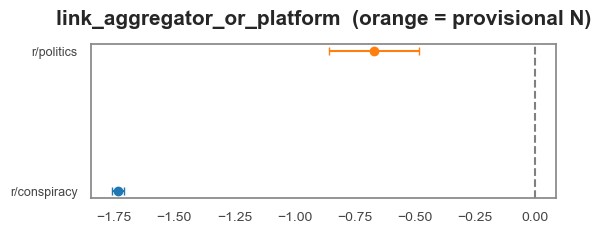

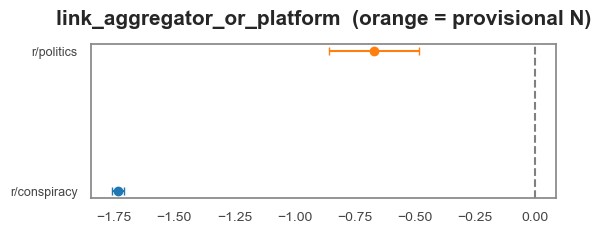

In [38]:
import matplotlib.pyplot as plt



forest(dfdict["link_source_tier_regression_results.csv"], "link_aggregator_or_platform")

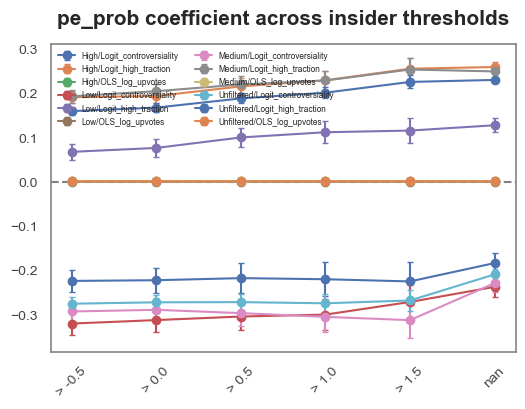

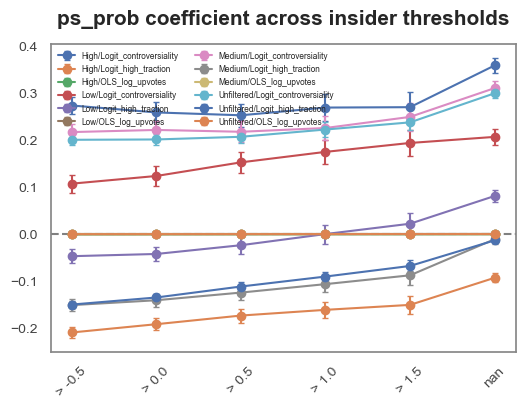

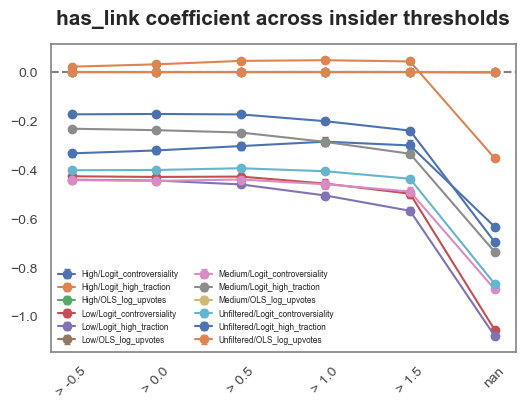

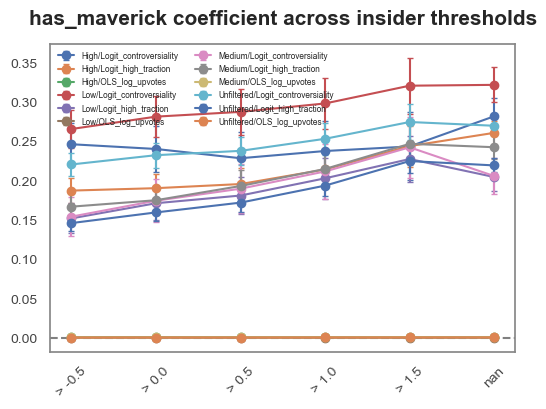

In [16]:
sf = dfdict["synthesis_regression_results_filtered.csv"]
order = ["None", "> -0.5", "> 0.0", "> 0.5", "> 1.0", "> 1.5"]
sf["insider_threshold"] = pd.Categorical(sf["insider_threshold"].astype(str), categories=order, ordered=True)

for var in ["pe_prob", "ps_prob", "has_link", "has_maverick"]:
    fig, ax = plt.subplots(figsize=(6,4))
    for strat, g in sf.sort_values("insider_threshold").groupby("elasticity_strata"):
        for model, gg in g.groupby("model_name"):
            ax.errorbar(gg["insider_threshold"].astype(str), gg[f"{var}_coef"],
                        yerr=1.96*gg[f"{var}_se"], label=f"{strat}/{model}", marker="o", capsize=2)
    ax.axhline(0, color="gray", ls="--")
    ax.set_title(f"{var} coefficient across insider thresholds")
    ax.legend(fontsize=6, ncol=2)
    plt.xticks(rotation=45)
    plt.show()

Text(0.5, 1.0, 'Implied has_link effect by subreddit')

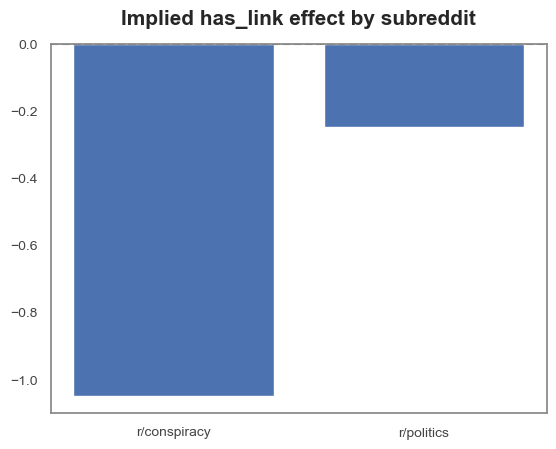

In [17]:
si = dfdict["subreddit_interaction_results.csv"].set_index("term")
base = si.loc["has_link", "coef"]
delta = si.loc["has_link:C(subreddit)[T.r/politics]", "coef"]
plt.bar(["r/conspiracy", "r/politics"], [base, base + delta])
plt.axhline(0, color="gray", ls="--")
plt.title("Implied has_link effect by subreddit")


In [25]:
def style_regression_table(df):
    d = df.copy()
    d["neg_log10_p"] = -np.log10(d["pvalue"].clip(lower=1e-300))
    d["neg_log10_p_capped"] = d["neg_log10_p"].clip(upper=20)  # cap so one underflow doesn't dominate the scale
    return (d.style
        .background_gradient(subset=["neg_log10_p_capped"], cmap="Reds")
        .apply(lambda r: ["background-color:#fff3cd" if pd.notna(r.get("note")) and r.get("note") else "" for _ in r], axis=1)
        .format({"coef":"{:.3f}", "se":"{:.3f}", "pvalue":"{:.2e}"}))

In [26]:


style_regression_table(dfdict["topic_time_regression_results_pure_50k.csv"])

,stratum,model_type,variable,coef,se,pvalue,n_obs,note,neg_log10_p,neg_log10_p_capped
0,Super-Topic: 9/11 & Structural Collapses,OLS (Log Upvotes),pe_prob,0.017,0.012,1.54e-01,1167,nan,0.812367,0.812367
1,Super-Topic: 9/11 & Structural Collapses,OLS (Log Upvotes),ps_prob,-0.007,0.010,5.09e-01,1167,nan,0.293163,0.293163
2,Super-Topic: 9/11 & Structural Collapses,OLS (Log Upvotes),has_link,0.002,0.005,7.18e-01,1167,nan,0.143990,0.143990
3,Super-Topic: 9/11 & Structural Collapses,OLS (Log Upvotes),has_maverick,-0.004,0.009,6.69e-01,1167,nan,0.174797,0.174797
4,Super-Topic: 9/11 & Structural Collapses,OLS (Log Upvotes),has_canonical_expert,0.000,0.000,nan,1167,nan,nan,nan
5,Super-Topic: 9/11 & Structural Collapses,OLS (Log Upvotes),log_char_length,0.002,0.003,5.83e-01,1167,nan,0.234667,0.234667
6,Super-Topic: 9/11 & Structural Collapses,OLS (Log Upvotes),has_consensus_expert,nan,nan,nan,1167,Dropped due to sparsity (<15 cases),nan,nan
7,Super-Topic: Outliers,OLS (Log Upvotes),pe_prob,0.004,0.002,1.14e-01,31013,nan,0.943564,0.943564
8,Super-Topic: Outliers,OLS (Log Upvotes),ps_prob,-0.001,0.002,7.42e-01,31013,nan,0.129629,0.129629
9,Super-Topic: Outliers,OLS (Log Upvotes),has_link,-0.011,0.001,9.21e-42,31013,nan,41.035966,20.000000


In [44]:
dfdict['synthesis_regression_results_filtered.csv'].columns

Index(['elasticity_strata', 'insider_threshold', 'model_name', 'n_obs',
       'r2_or_pseudo_r2', 'model_sig_pvalue', 'pe_prob_coef', 'pe_prob_se',
       'pe_prob_pvalue', 'pe_prob_tstat', 'ps_prob_coef', 'ps_prob_se',
       'ps_prob_pvalue', 'ps_prob_tstat', 'has_link_coef', 'has_link_se',
       'has_link_pvalue', 'has_link_tstat', 'has_maverick_coef',
       'has_maverick_se', 'has_maverick_pvalue', 'has_maverick_tstat',
       'pe_prob_p_bh', 'ps_prob_p_bh', 'has_link_p_bh', 'has_maverick_p_bh'],
      dtype='object')

In [43]:


style_regression_table(dfdict['synthesis_regression_results_filtered.csv'])

KeyError: 'pvalue'

In [19]:
from scipy.stats import false_discovery_control  # or implement BH manually if scipy is old

def add_bh(df, p_col="pvalue"):
    df = df.copy()
    mask = df[p_col].notna()
    df.loc[mask, "p_bh"] = false_discovery_control(df.loc[mask, p_col])
    return df

topic_time = add_bh(dfdict["topic_time_regression_results_pure_50k.csv"])
topic_time[topic_time["p_bh"] < 0.05]


,stratum,model_type,variable,coef,se,pvalue,n_obs,note,p_bh
9,Super-Topic: Outliers,OLS (Log Upvotes),has_link,-0.011385,0.000840,9.205219e-42,31013,NaN,5.615184e-40
13,Super-Topic: Outliers,OLS (Log Upvotes),log_char_length,-0.002174,0.000508,1.876774e-05,31013,NaN,2.544072e-04
113,Era: Political Realignment Era (2016-2019),Logit (High Traction),ps_prob,-0.549210,0.125749,1.256688e-05,11422,NaN,1.916450e-04
114,Era: Political Realignment Era (2016-2019),Logit (High Traction),has_link,0.505006,0.081846,6.819300e-10,11422,NaN,1.663909e-08
117,Era: Political Realignment Era (2016-2019),Logit (High Traction),log_char_length,0.128260,0.040274,1.449254e-03,11422,NaN,1.473408e-02
121,Era: Political Realignment Era (2016-2019),OLS (Log Upvotes),has_link,-0.008037,0.001722,3.085649e-06,11422,NaN,5.377846e-05
126,Era: Pandemic & Modern Era (2020-2025),Logit (High Traction),pe_prob,-0.353017,0.103168,6.221718e-04,35312,NaN,6.900450e-03
127,Era: Pandemic & Modern Era (2020-2025),Logit (High Traction),ps_prob,-0.475900,0.081368,4.952878e-09,35312,NaN,1.007085e-07
128,Era: Pandemic & Modern Era (2020-2025),Logit (High Traction),has_link,0.999434,0.053969,1.461779e-76,35312,NaN,1.783370e-74
129,Era: Pandemic & Modern Era (2020-2025),Logit (High Traction),has_maverick,-0.272084,0.065441,3.214505e-05,35312,NaN,3.921696e-04


Text(0.5, 1.0, 'Top keyness terms: canonical vs consensus, r/conspiracy')

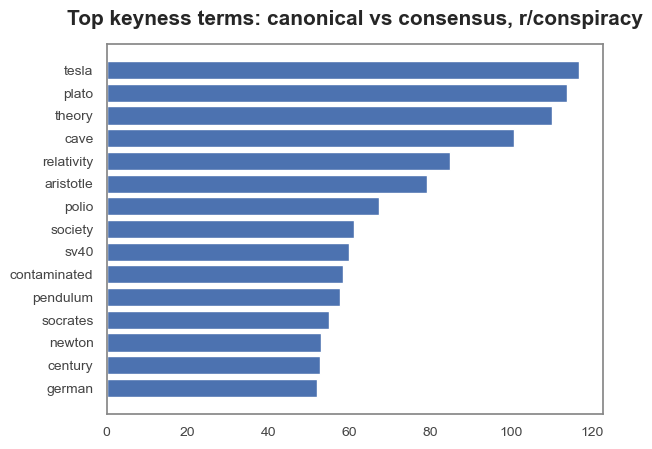

In [20]:
kw = dfdict["refined_semantic_keyness_results_v2.csv"]
top = (kw[(kw["comparison"]=="canonical_vs_consensus") & (kw["subreddit"]=="r/conspiracy")]
       .nlargest(15, "log_likelihood"))
plt.barh(top["word"], top["log_likelihood"])
plt.gca().invert_yaxis()
plt.title("Top keyness terms: canonical vs consensus, r/conspiracy")

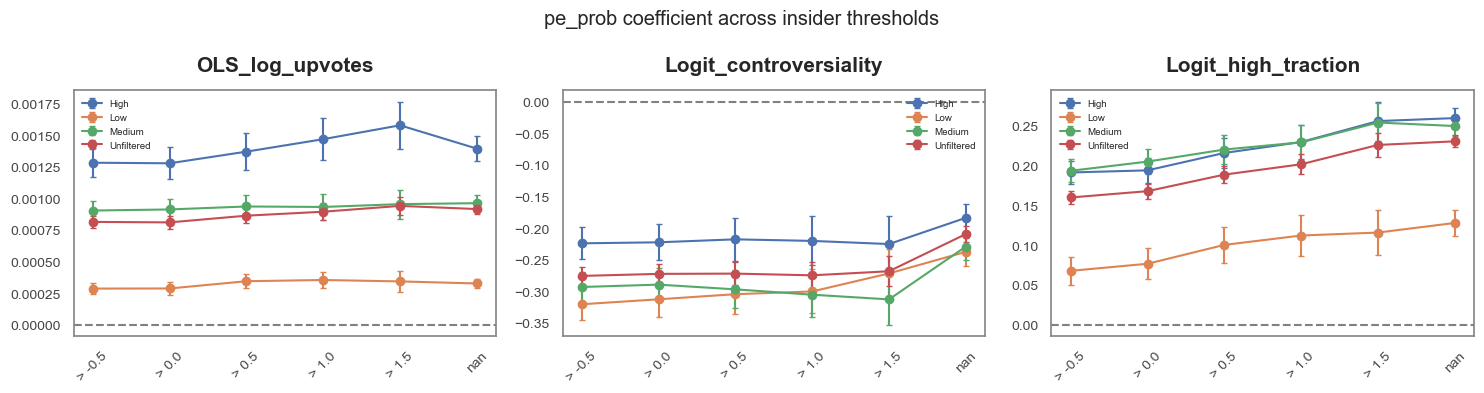

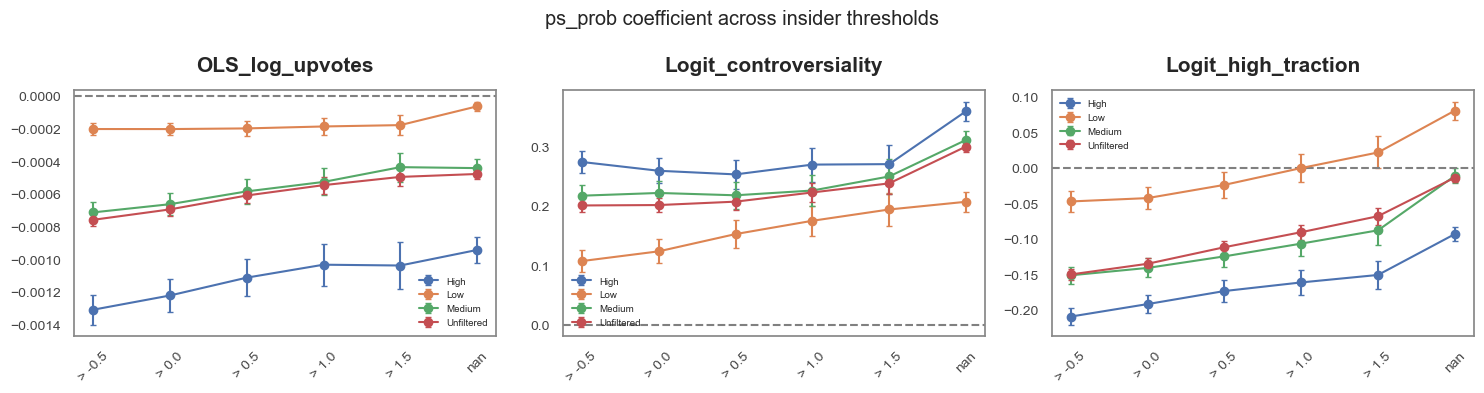

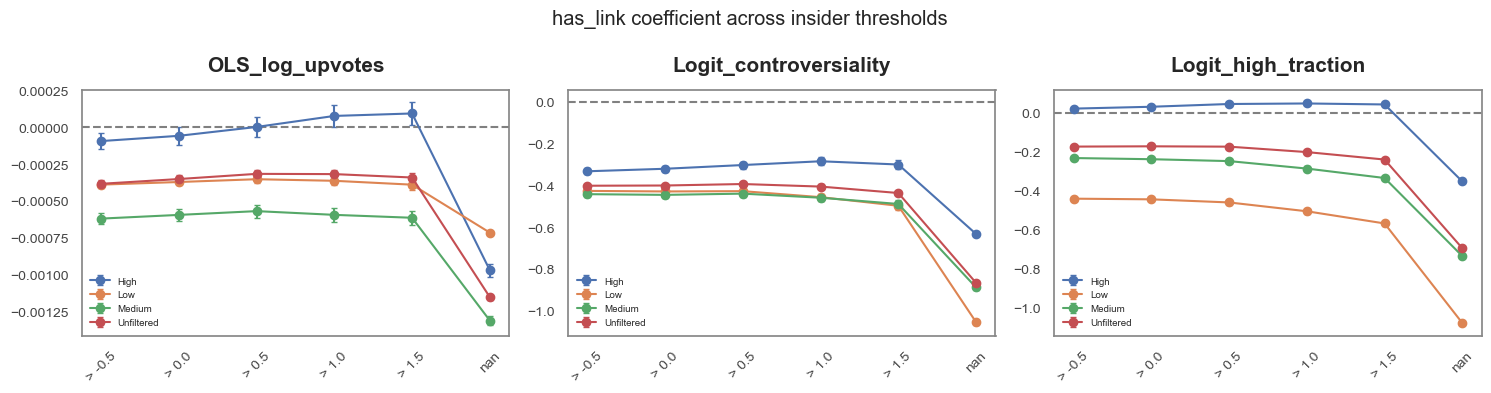

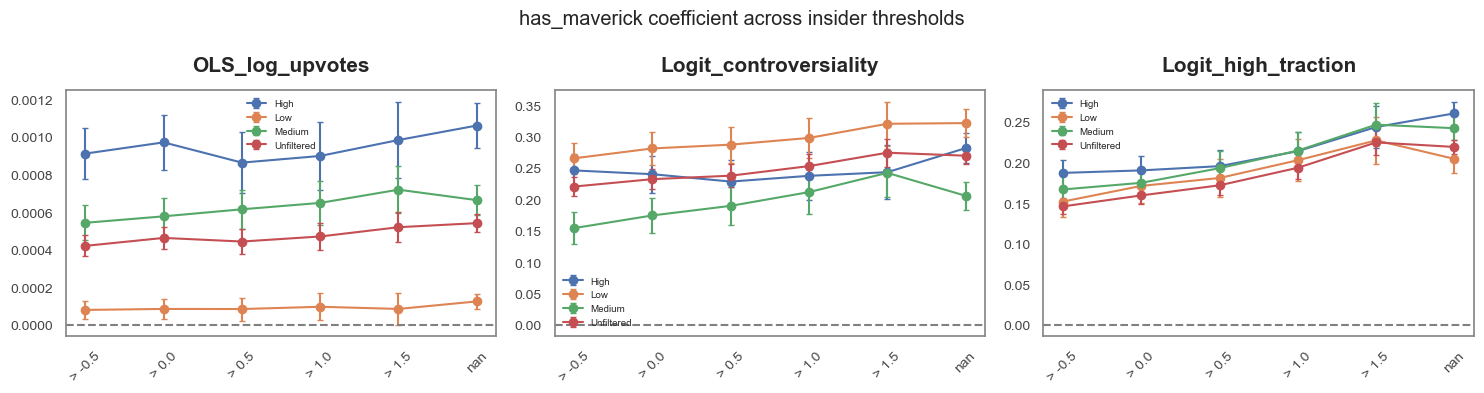

In [21]:
for var in ["pe_prob", "ps_prob", "has_link", "has_maverick"]:
    models = sf["model_name"].unique()
    fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4), sharex=False)
    for ax, model in zip(axes, models):
        g = sf[sf["model_name"] == model]
        for strat, gg in g.sort_values("insider_threshold").groupby("elasticity_strata"):
            ax.errorbar(gg["insider_threshold"].astype(str), gg[f"{var}_coef"],
                        yerr=1.96*gg[f"{var}_se"], label=strat, marker="o", capsize=2)
        ax.axhline(0, color="gray", ls="--")
        ax.set_title(f"{model}")
        ax.legend(fontsize=7)
        ax.tick_params(axis='x', rotation=45)
    fig.suptitle(f"{var} coefficient across insider thresholds")
    fig.tight_layout()
    plt.show()

In [39]:
compare = pd.DataFrame([
    {"population": "Whole corpus (Unfiltered)", "coef": sf.loc[
        (sf["elasticity_strata"]=="Unfiltered") & (sf["insider_threshold"]=="None") & (sf["model_name"]=="Logit_high_traction"),
        "has_link_coef"].values[0]},
    {"population": "Pure slice (v2)", "coef": dfdict["refined_regression_results_v2.csv"]
        .query("subreddit=='r/conspiracy' and variable=='has_link'")["coef"].values[0]},
])
compare

IndexError: index 0 is out of bounds for axis 0 with size 0

In [40]:
def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

def paper_table(df, cohort_col="subreddit"):
    d = df.copy()
    d["cell"] = d.apply(lambda r: f"{r['coef']:.3f}{stars(r['pvalue'])}\n({r['se']:.3f})", axis=1)
    return d.pivot(index="variable", columns=cohort_col, values="cell")

paper_table(dfdict["refined_regression_results_v2.csv"])

subreddit,r/conspiracy,r/politics
variable,,
has_canonical_expert,0.033\n(0.051),0.157\n(0.474)
has_consensus_expert,0.528***\n(0.068),-0.158\n(0.397)
has_link,-1.049***\n(0.009),-0.247***\n(0.058)
has_maverick,0.248***\n(0.010),0.544***\n(0.122)
log_char_length,-0.192***\n(0.004),-0.081***\n(0.018)
pe_prob,0.307***\n(0.016),0.069\n(0.108)
ps_prob,0.207***\n(0.013),-0.404***\n(0.097)


In [41]:
status_rows = []
for fname, df in dfdict.items():
    status_rows.append({
        "file": fname,
        "shape": shapes[fname],
        "usable": shapes[fname] != "broken_broadcast_bug",
        "has_provisional_rows": bool(df.get("provisional_n", pd.Series(dtype=bool)).any()) if "provisional_n" in df.columns else None,
        "n_obs_range": f"{df['n_obs'].min()}–{df['n_obs'].max()}" if "n_obs" in df.columns else None,
    })
pd.DataFrame(status_rows)

,file,shape,usable,has_provisional_rows,n_obs_range
0,link_source_tier_regression_results.csv,tidy_regression,True,True,30881–1968864
1,trump_vs_classical_regression_results.csv,tidy_regression,True,False,5286–35179
2,politics_overlap_excluded_comparison.csv,broken_broadcast_bug,False,None,None
3,subreddit_interaction_results.csv,tidy_regression,True,None,1999745–1999745
4,refined_semantic_keyness_results_v2.csv,keyness,True,None,None
5,refined_regression_results_v2.csv,tidy_regression,True,True,30881–1968864
6,topic_time_regression_results_pure_50k.csv,tidy_regression,True,False,1167–35312
7,synthesis_interaction_results.csv,tidy_regression,True,None,16735472–16735472
8,synthesis_regression_results_filtered.csv,wide_regression,True,None,1275407–16735472


In [42]:
sig = master.pivot_table(index="variable", columns="cohort",
                          values="pvalue", aggfunc=lambda p: stars(p.iloc[0]) if len(p) else "")
sig

NameError: name 'master' is not defined

In [3]:
ats = pd.read_json(BASE +"ats_comments_sample.jsonl", lines = True)

In [4]:
ats

,thread_id,thread_title,page_num,post_id,author,raw_timestamp,body
0,0,"Greetings, ATS",1,17597750,IgnoreDenial,"feb, 28 2014 @ 09:17 am","Hey folks, this is IgnoreDenial reporting in, from planet Earth! I have been lurking here for a long time, but now it seems that the day has finally\narrived when I need to make my presence felt in this forum. \n\nMy philosophy here is to ignore those who deny the facts in the face of overwhelming evidence. Of course, there is a tiny chance that all the evidence\npresented in support of a theory is fake (for examples, generated by faulty sensing equipment or fabricated by a nefarious organisation), in which\ncase the deniers will survive and go on to re-populate the planet. This strategy is similar to a mutant bacterium surviving a dose of the latest\nanti-biotic, and then re-infecting its host."
1,0,"Greetings, ATS",1,17597757,DISRAELI,"feb, 28 2014 @ 09:20 am","reply to post by IgnoreDenial \n \nWelcome to ATS. \nYou may like to know that this is the very first publicly visible thread on ATS with a thread number over one million; \nThis is something I've been predicting all week. \nYou are actually one million and one (the ""millionth"" thread was evidently in the private staff forums)."
2,0,"Greetings, ATS",1,17597791,natalia,"feb, 28 2014 @ 09:30 am",reply to post by IgnoreDenial \n \n\nGlad you introduced yourself. I hope you've been enjoying it here and continue to do so \nHave a welcome fruit cake \nHave a wonderful day! \nPeace and love \n-nat
3,0,"Greetings, ATS",1,17597804,Destinyone,"feb, 28 2014 @ 09:33 am","reply to post by IgnoreDenial \n \n\nWelcome to the rabbit hole. Glad you decided to take the plunge, Here's your pills.... \n\nChoose wisely, IgnoreDenial... \n\n \n\nSee ya in the forums. \n\nDes"
4,0,"Greetings, ATS",1,17597808,IgnoreDenial,"feb, 28 2014 @ 09:34 am","DISRAELI \nreply to post by IgnoreDenial \n \nWelcome to ATS. \nYou may like to know that this is the very first publicly visible thread on ATS with a thread number over one million; \nThis is something I've been predicting all week. \nYou are actually one million and one (the ""millionth"" thread was evidently in the private staff forums). \n\n \n\nThis is nothing, the last time I visited Earth, the people reset their calendars and stared counting the years from '0001'! Then, after a few years,\nthey killed me in a very painful manner for some weird reason only they could understand. \n\nI hope I get better treatment here. I have been told that the times have changed, and less people are getting killed over silly reasons than\nbefore!"
5,0,"Greetings, ATS",1,17597821,DISRAELI,"feb, 28 2014 @ 09:38 am",DISRAELI \nYou may like to know that this is the very first publicly visible thread on ATS with a thread number over one million; \nThis is something I've been predicting all week. \n \nP.S. ATS Thread One Million
6,0,"Greetings, ATS",1,17597822,Wrabbit2000,"feb, 28 2014 @ 09:38 am","Hello IgnoreDenial! \nYou'll find around 100 forums here, covering everything from Ancient Civilizations to\nBreaking News to Political Events and much more. All are welcome and everyone can contribute equally, so please come right in and make yourself\nat home! \n\nFor now, you are only able to post to existing threads or, if you need help, send private messages to Staff as well as the\nComplaint and Suggestion form. Once you've contributed some posts to threads\naround the site, you'll be able to make your own threads for others to enjoy. \n\nThere are also a few threads you'll want to look over as soon as you get the chance. They are important and helpful too! \n\nTerms and Conditions /\nReaffirming ATS Policies \n\nUsing the Features of ATS /\nAvatar Upload Instructions \n\nStarting a New Thread ?... Look Here First. \n\nFrequently Asked Questions Of All Kinds! \n\nMore tips, tricks and help can be found in the Freshmen's Forum or\nBoard Business & Questions forum. \nRemember, Have Fun!"
7,0,"Greetings, ATS",1,17612170,manta78,